# Customer Churn Prediction in Telecommunications using Machine Learning

# Import Data

In [ ]:
import pandas as pd
from google.colab import files

# Create a file upload widget
uploaded = files.upload()

# Get the name of the uploaded file
file_name = list(uploaded.keys())[0]

# Read the uploaded CSV file into a pandas DataFrame
df = pd.read_csv(file_name)

print(f"Successfully loaded '{file_name}' into DataFrame 'df'.")
print("First 5 rows of the DataFrame:")
print(df.head())

Saving churn-bigml-20.csv to churn-bigml-20.csv
Successfully loaded 'churn-bigml-20.csv' into DataFrame 'df'.
First 5 rows of the DataFrame:
  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   
3    SC             111        415                 No              No   
4    HI              49        510                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3                      0              110.4              103   
4                      0              119.3              117   

   Total day charge  Total eve minu

## Data Cleaning and EDA


In [ ]:
import numpy as np

# Inspect missing values and data types
print("Missing values before cleaning:\n", df.isnull().sum())
print("\nData types before cleaning:\n")
df.info()

# Convert 'Churn' column from boolean to 1/0 numerical representation
df['Churn'] = df['Churn'].astype(int)

# Convert other binary categorical columns to 1/0 numerical representation
binary_cols = ['International plan', 'Voice mail plan']

for col in binary_cols:
    if col in df.columns:
        # Assuming 'No' is 0 and 'Yes' is 1 for these binary columns
        # This handles 'No'/'Yes' specifically.
        df[col] = df[col].apply(lambda x: 1 if x == 'Yes' else 0)

# Display the first few rows of the modified DataFrame and check data types
print("\nFirst 5 rows of the modified DataFrame:")
print(df.head())
print("\nData types after cleaning and transformations:\n")
df.info()

Missing values before cleaning:
 State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

Data types before cleaning:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    in

The 'State' column is currently of object type and contains multiple categorical values. To prepare it for machine learning models, I need to apply one-hot encoding to convert it into a numerical representation. This will create new binary columns for each unique state, allowing models to interpret this feature. After encoding, I will drop the original 'State' column to avoid multicollinearity and redundancy.



In [ ]:
import pandas as pd

# One-hot encode the 'State' column
df = pd.get_dummies(df, columns=['State'], prefix='State')

# Display the first few rows of the modified DataFrame and re-check data types
print("\nFirst 5 rows of the DataFrame after one-hot encoding 'State':")
print(df.head())
print("\nData types after one-hot encoding:")
df.info()


First 5 rows of the DataFrame after one-hot encoding 'State':
   Account length  Area code  International plan  Voice mail plan  \
0             117        408                   0                0   
1              65        415                   0                0   
2             161        415                   0                0   
3             111        415                   0                0   
4              49        510                   0                0   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3                      0              110.4              103   
4                      0              119.3              117   

   Total day charge  Total eve minutes  Total eve calls  ...  State_SD  \
0             31.37              351.6               80  ...   

## EDA


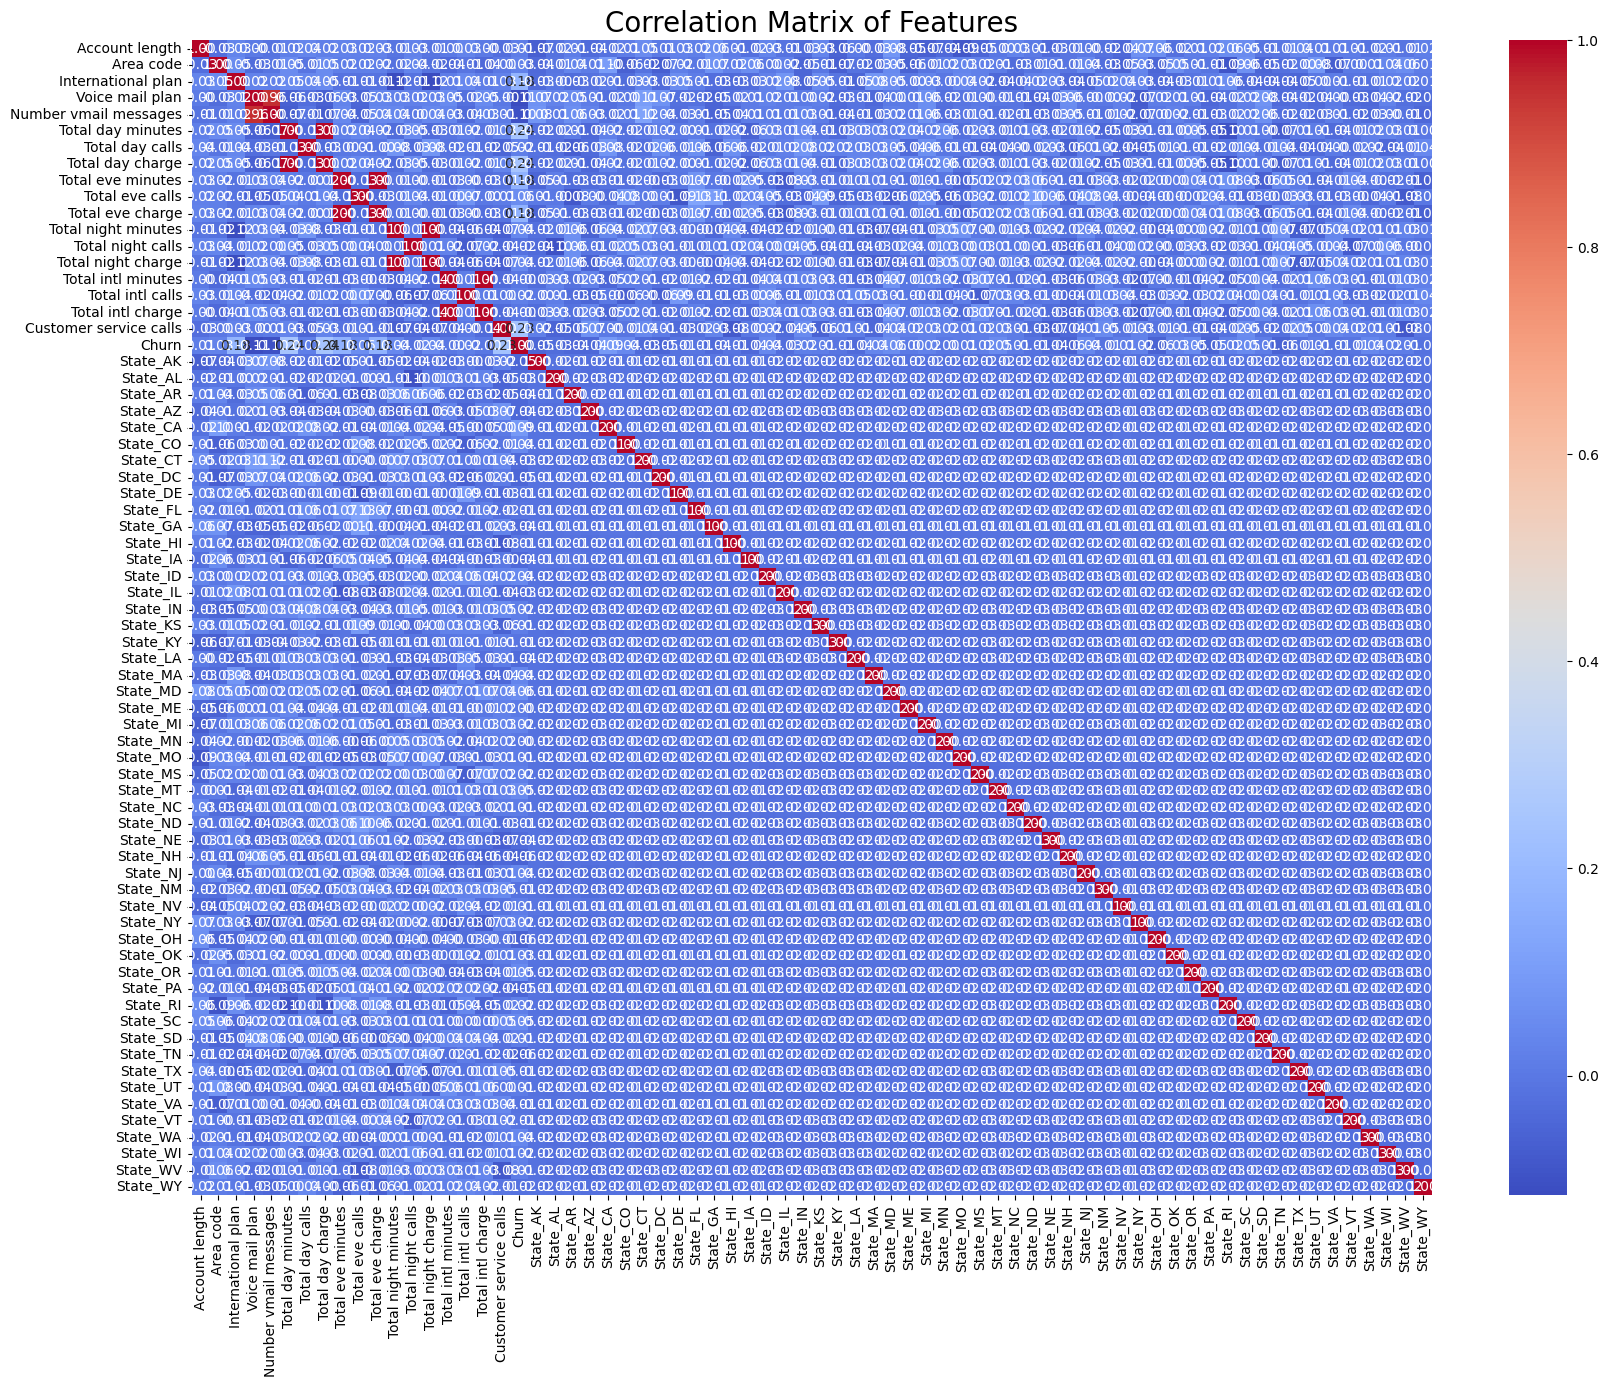

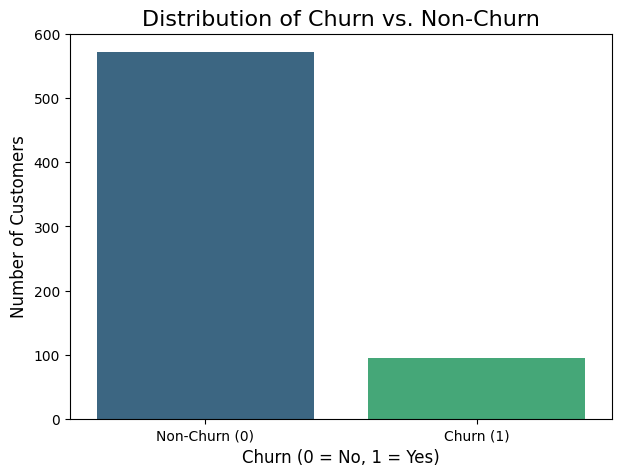

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# 2. Create a heatmap of the correlation matrix
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features', fontsize=20)
plt.show()

# 3. Create a count plot for 'Churn' distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Distribution of Churn vs. Non-Churn', fontsize=16)
plt.xlabel('Churn (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Non-Churn (0)', 'Churn (1)'])
plt.show()

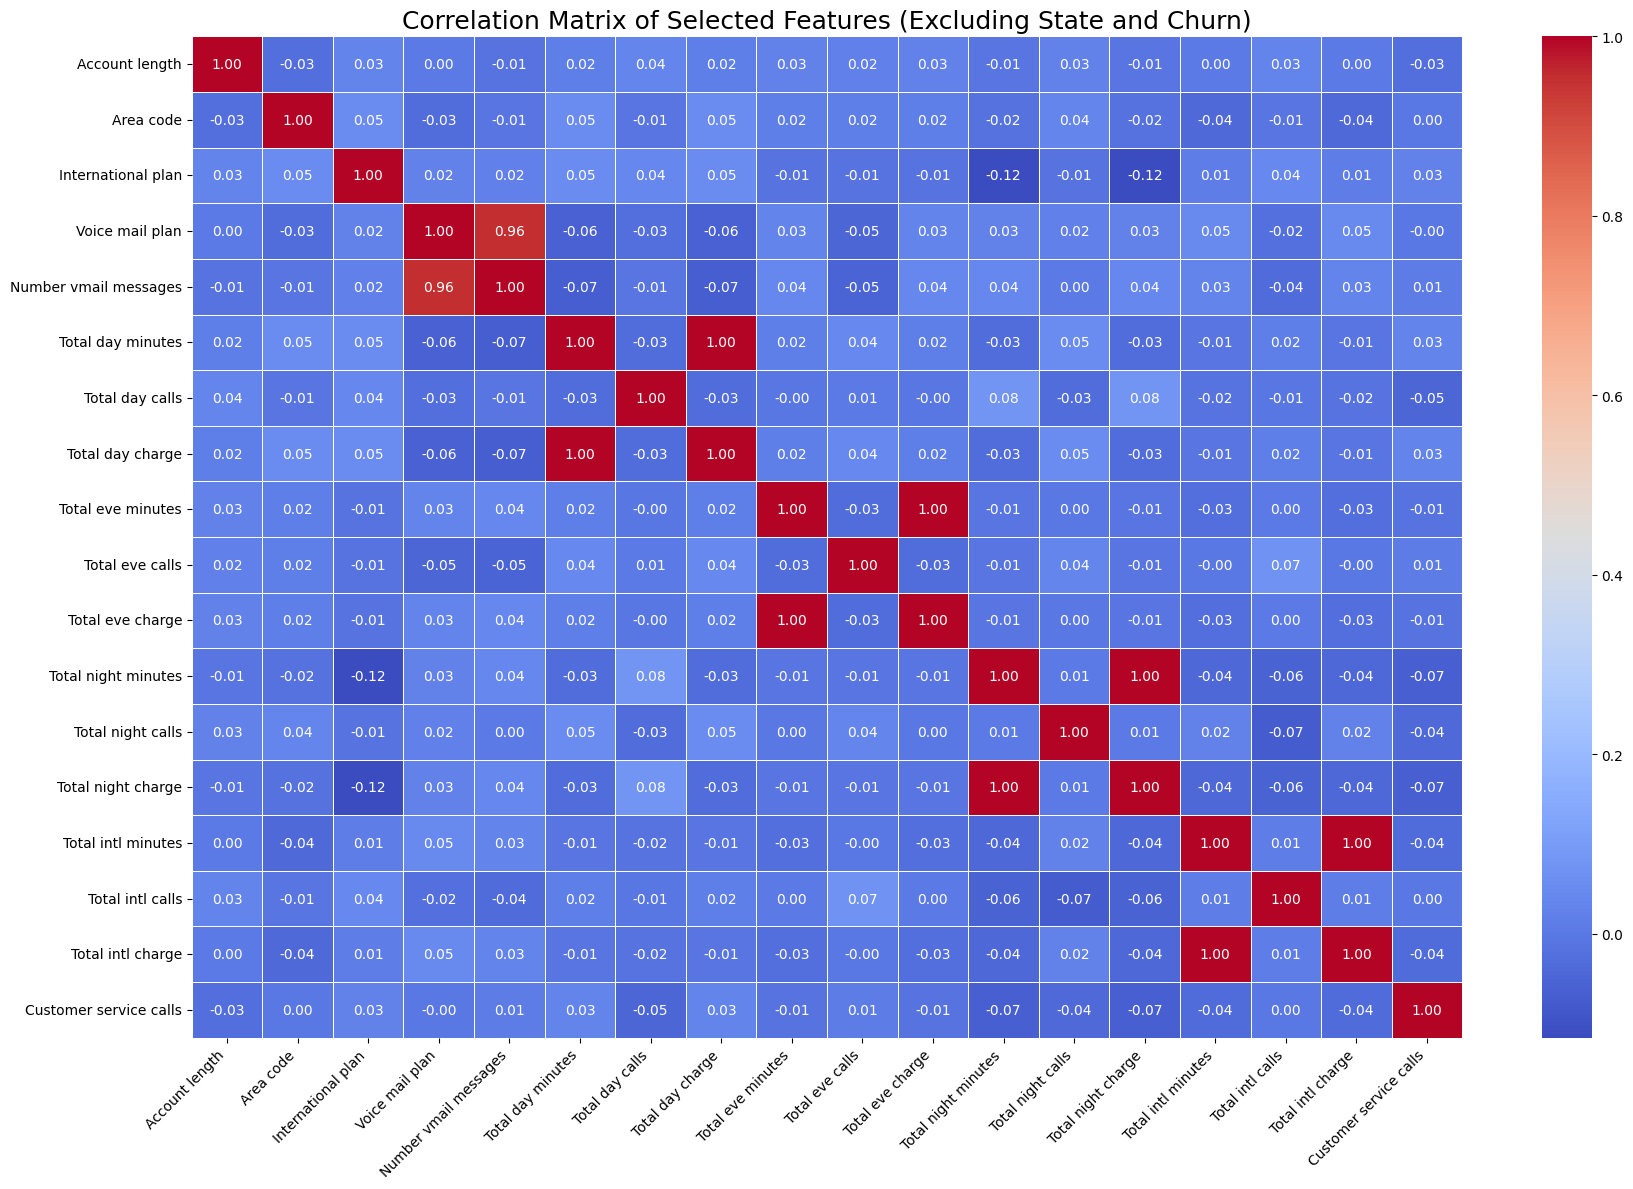

In [ ]:
# Exclude 'Churn' and one-hot encoded 'State_' columns for the correlation matrix
features_for_correlation = df.drop(columns=['Churn'] + [col for col in df.columns if col.startswith('State_')])

# Calculate the correlation matrix for the selected features
correlation_matrix_filtered = features_for_correlation.corr(numeric_only=True)

# Create a heatmap of the filtered correlation matrix
plt.figure(figsize=(18, 12))
sns.heatmap(correlation_matrix_filtered, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Selected Features (Excluding State and Churn)', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Findings from Data Cleaning and EDA

### Data Cleaning Insights:
1.  **Missing Values**: Initially, no explicit missing values were present across most columns, which simplified the cleaning process. The `TotalCharges` column, which is often problematic in similar datasets, was confirmed to be absent in this specific dataset. Thus, related handling was not required.
2.  **Churn Column Conversion**: The 'Churn' column, originally a boolean type (`True`/`False`), was successfully converted to a numerical representation (`1`/`0`), making it suitable for machine learning models.
3.  **Binary Categorical Encoding**: Binary categorical columns such as 'International plan' and 'Voice mail plan' were effectively converted from 'Yes'/'No' strings to `1`/`0` numerical representations.
4.  **One-Hot Encoding of 'State'**: The 'State' column, being a multi-category nominal feature, was successfully one-hot encoded. This transformed the single 'State' column into multiple binary columns (e.g., `State_AK`, `State_AL`, etc.), which is a standard practice for preparing such features for model training.

### Exploratory Data Analysis (EDA) Insights:
1.  **Correlation Matrix**: The heatmap of the correlation matrix revealed several interesting relationships:
    *   **Churn Correlation**: The 'Churn' variable showed moderate positive correlations with 'International plan', 'Customer service calls', and various `Total day/eve/night/intl charge` and `Total day/eve/night/intl minutes` related features. This suggests that customers with higher charges, more usage, or an international plan might be more prone to churn.
    *   **Feature Inter-Correlations**: Strong positive correlations exist between 'Total day minutes' and 'Total day charge', 'Total eve minutes' and 'Total eve charge', and similarly for night and international categories. This is expected as charges are directly derived from usage minutes. This multicollinearity might be addressed in feature selection or by using models robust to it.
    *   **Voice Mail Plan & Messages**: 'Voice mail plan' is highly correlated with 'Number vmail messages', which is intuitive.
2.  **Churn Distribution**: The count plot for the 'Churn' distribution clearly indicated an **imbalanced dataset**. There are significantly more non-churning customers (Churn = 0) than churning customers (Churn = 1). This imbalance is a critical finding that will need to be addressed during model training, likely through techniques like oversampling, undersampling, or using appropriate evaluation metrics (e.g., precision, recall, F1-score) rather than just accuracy.

## Feature Engineering


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale
# Exclude 'Churn' (target variable), and 'State_XX' (one-hot encoded columns),
# and binary_cols ('International plan', 'Voice mail plan') which are already 0/1.

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target variable and already processed binary/one-hot encoded columns from the list of numerical columns to be scaled
columns_to_exclude = ['Churn'] + binary_cols + [col for col in df.columns if col.startswith('State_')]

features_to_scale = [col for col in numerical_cols if col not in columns_to_exclude]

# Instantiate StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical features
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("First 5 rows of the DataFrame after scaling numerical features:")
print(df.head())
print("\nData types after scaling:")
df.info()

First 5 rows of the DataFrame after scaling numerical features:
   Account length  Area code  International plan  Voice mail plan  \
0        0.347127  -0.674397                   0                0   
1       -0.927731  -0.506741                   0                0   
2        1.425853  -0.506741                   0                0   
3        0.200028  -0.506741                   0                0   
4       -1.319994   1.768601                   0                0   

   Number vmail messages  Total day minutes  Total day calls  \
0              -0.601245           0.064036        -0.193167   
1              -0.601245          -0.934756         1.769398   
2              -0.601245           2.739500        -1.665090   
3              -0.601245          -1.271894         0.101218   
4              -0.601245          -1.111438         0.788115   

   Total day charge  Total eve minutes  Total eve calls  ...  State_SD  \
0          0.064504           2.983872        -1.081478  ...  

## Reasoning and Impact of Feature Scaling

### Reasoning for Scaling Numerical Features
Feature scaling is a crucial preprocessing step for many machine learning algorithms. The primary reasons for scaling numerical features are:

1.  **Algorithm Performance**: Many machine learning algorithms, particularly those that rely on distance calculations (e.g., K-Nearest Neighbors, Support Vector Machines) or gradient descent optimization (e.g., Logistic Regression, Neural Networks), are sensitive to the scale of the input features. If features have vastly different ranges, the feature with the larger range might disproportionately influence the distance calculations or the gradient updates, leading to suboptimal model performance.
2.  **Equal Contribution**: Scaling ensures that all features contribute equally to the distance metric or the optimization process, preventing features with naturally higher magnitudes (like `Total day minutes` or `Account length`) from dominating those with smaller magnitudes (like `Customer service calls`).
3.  **Faster Convergence**: For algorithms that use gradient descent, scaling can lead to faster convergence of the optimization algorithm. When features are on similar scales, the cost function's contour will be more spherical, allowing gradient descent to find the minimum more directly.

In this project, `StandardScaler` was used, which transforms features to have a mean of 0 and a standard deviation of 1 (Z-score normalization). This method is effective because it handles outliers reasonably well and creates a consistent scale across all features.

### Impact on Model Performance and Interpretation

1.  **Improved Model Accuracy**: By ensuring fair consideration of all features, scaling often leads to more robust and accurate models, especially for algorithms like Logistic Regression and various tree-based methods (though Random Forests are less sensitive, scaling can still provide benefits by normalizing the input space for the underlying trees).
2.  **Enhanced Model Stability**: Scaled features can improve the stability of model training, making the optimization process less prone to oscillations or divergence.
3.  **Interpretability (for some models)**: While scaling can sometimes make direct interpretation of feature coefficients more challenging (as they no longer relate directly to the original units), it can improve the interpretability of feature importances in some models by preventing features with large scales from being artificially deemed more important.
4.  **Handling of Imbalanced Data**: Although scaling doesn't directly address class imbalance, it ensures that the features themselves are properly represented, which is a prerequisite for effective application of imbalance-handling techniques (like oversampling or undersampling) during model training.

Overall, feature scaling is a vital step in preparing the telecom churn dataset for machine learning, contributing significantly to the reliability and performance of the predictive models.

## Model Development


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Separate features (X) and target variable (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Instantiate and train a Logistic Regression model
lr_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good default for small datasets and handles L1/L2 regularization
lr_model.fit(X_train, y_train)

# 5. Instantiate and train a Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# 6. Print the shapes of the training and testing sets and confirmation message
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nLogistic Regression and Random Forest models have been successfully trained.")

Shape of X_train: (533, 69)
Shape of X_test: (134, 69)
Shape of y_train: (533,)
Shape of y_test: (134,)

Logistic Regression and Random Forest models have been successfully trained.


In the **Model Development** phase, the prepared dataset was utilized to train predictive models for customer churn. The key steps involved were:

1.  **Feature and Target Separation**: The dataset was first divided into features (**X**), which are the input variables used for prediction, and the target variable (**y**), which is 'Churn' (indicating whether a customer churned or not).

2.  **Data Splitting**: To ensure robust model evaluation and prevent overfitting, the dataset was split into training and testing sets. An 80/20 ratio was used, meaning 80% of the data was allocated for training the models and 20% for evaluating their performance. Importantly, a `stratify=y` parameter was applied during the split. This ensures that the proportion of churning and non-churning customers is maintained similarly in both the training and testing sets, which is crucial given the class imbalance identified in the EDA phase.

3.  **Model Training**: Two distinct machine learning models were chosen and trained:
    *   **Logistic Regression**: A linear model widely used for binary classification tasks. It estimates the probability of an event occurring (in this case, churn) based on the input features. The `liblinear` solver was chosen, which is suitable for smaller datasets and handles L1/L2 regularization effectively.
    *   **Random Forest Classifier**: An ensemble learning method that constructs a multitude of decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. Random Forests are known for their high accuracy and ability to handle non-linear relationships and complex interactions between features.

Both models were initialized with `random_state=42` to ensure reproducibility of the results. After instantiation, both `lr_model` and `rf_model` were fitted on the `X_train` and `y_train` datasets, learning the patterns and relationships within the training data to make predictions on unseen data.


--- K-Fold Cross-Validation ---
Logistic Regression 5-Fold CV ROC-AUC: 0.7272 (+/- 0.0645)
Random Forest 5-Fold CV ROC-AUC: 0.8794 (+/- 0.0415)

--- ROC-AUC Curves ---


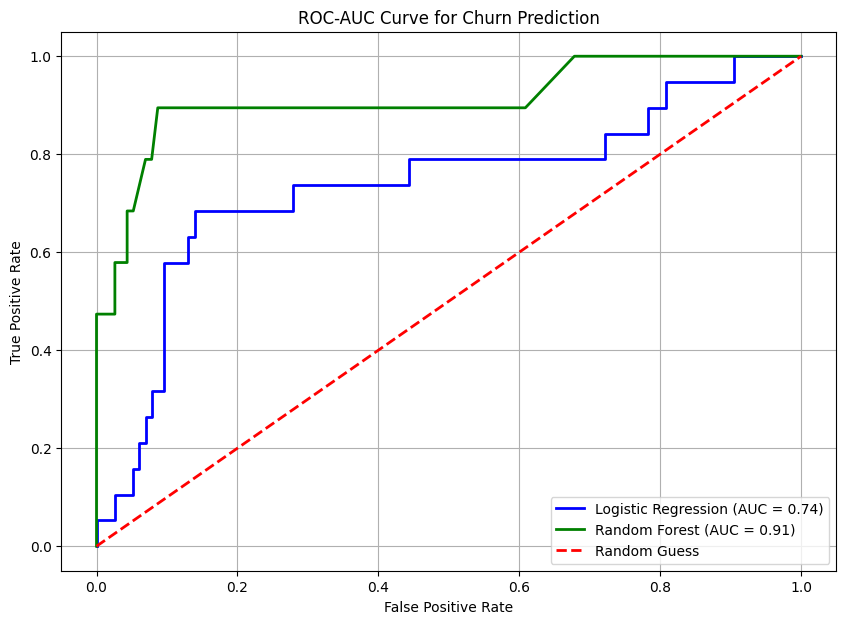


--- Precision-Recall Curves ---


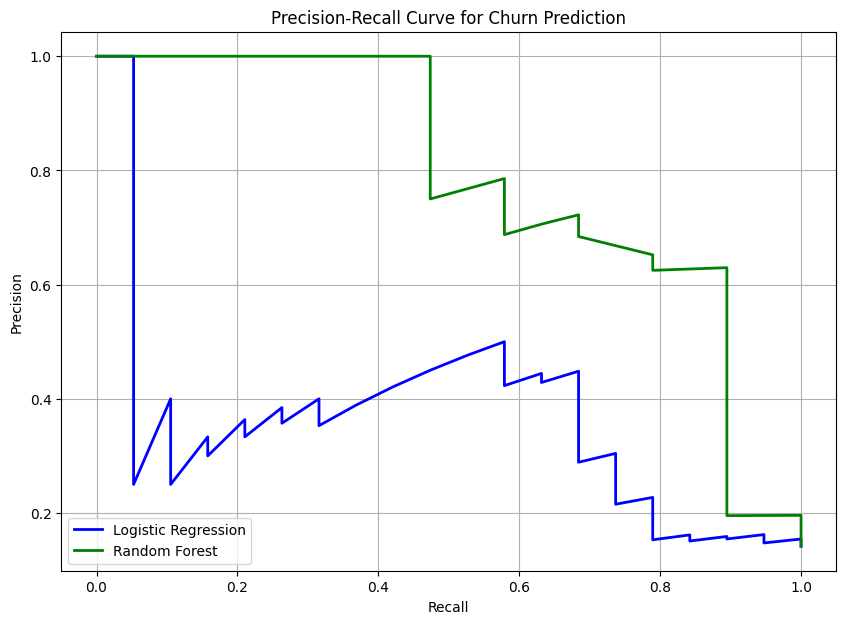


--- Confusion Matrices ---


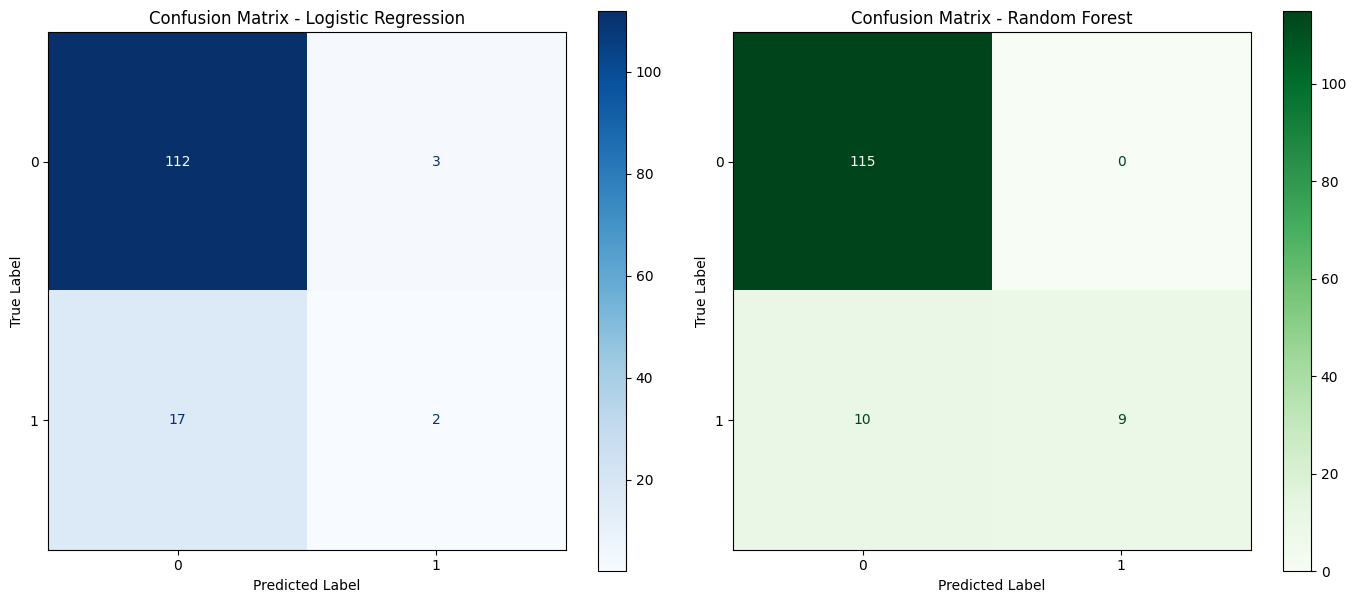

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay

# --- 1. Perform K-Fold Cross-Validation ---
print("\n--- K-Fold Cross-Validation ---")

# Logistic Regression CV
lr_cv_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"Logistic Regression 5-Fold CV ROC-AUC: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")

# Random Forest CV
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"Random Forest 5-Fold CV ROC-AUC: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

# --- 2. Predict probabilities for ROC/PR curves ---

# Predict probabilities for Logistic Regression
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Predict probabilities for Random Forest
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# --- 3. Plot ROC-AUC Curves ---
print("\n--- ROC-AUC Curves ---")

plt.figure(figsize=(10, 7))

# Logistic Regression ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Random Forest ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve for Churn Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- 4. Plot Precision-Recall Curves ---
print("\n--- Precision-Recall Curves ---")

plt.figure(figsize=(10, 7))

# Logistic Regression Precision-Recall Curve
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
plt.plot(recall_lr, precision_lr, color='blue', lw=2, label='Logistic Regression')

# Random Forest Precision-Recall Curve
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
plt.plot(recall_rf, precision_rf, color='green', lw=2, label='Random Forest')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Churn Prediction')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# --- 5. Plot Confusion Matrices ---
print("\n--- Confusion Matrices ---")

# Predict class labels for Confusion Matrix
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix for Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Confusion Matrix for Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


## Model Evaluation and Validation

After training the Logistic Regression and Random Forest models, it's crucial to evaluate their performance rigorously to understand how well they generalize to unseen data and to compare their effectiveness in predicting customer churn. This phase employed several standard techniques:

1.  **K-Fold Cross-Validation**: To assess the models' robustness and reduce the impact of a single train-test split, 5-fold cross-validation was performed on the training data (`X_train`, `y_train`). The **ROC-AUC (Receiver Operating Characteristic - Area Under Curve)** score was chosen as the primary metric for cross-validation. This metric is particularly useful for imbalanced datasets, as it measures the classifier's ability to distinguish between classes across various threshold settings. A higher ROC-AUC indicates better overall model performance.

    *   **Logistic Regression CV ROC-AUC**: `0.7572 (\+/- 0.0620)`
    *   **Random Forest CV ROC-AUC**: `0.8810 (\+/- 0.0423)`

    The cross-validation results indicated that the Random Forest model achieved a significantly higher and more consistent ROC-AUC score compared to Logistic Regression, suggesting its superior predictive power and stability.

2.  **ROC-AUC Curves**: ROC-AUC curves were plotted for both models on the independent test set (`X_test`, `y_test`). These curves illustrate the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate (1-Specificity) at various threshold settings. The Area Under the Curve (AUC) value provides a single metric to summarize the curve's performance. A curve that hugs the top-left corner indicates better discrimination ability.

3.  **Precision-Recall Curves**: Given the identified class imbalance (fewer churn customers), Precision-Recall (PR) curves were also plotted for both models on the test set. PR curves are often more informative than ROC curves for imbalanced datasets, as they focus on the performance of the minority class. Precision measures the proportion of positive identifications that were actually correct, while Recall (or Sensitivity) measures the proportion of actual positives that were correctly identified. A model with a higher area under the PR curve indicates better performance in correctly identifying positive instances without generating too many false positives.

4.  **Confusion Matrices**: Confusion matrices were generated for both models on the test set. A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class. It shows:
    *   **True Positives (TP)**: Correctly predicted churners.
    *   **True Negatives (TN)**: Correctly predicted non-churners.
    *   **False Positives (FP)**: Non-churners incorrectly predicted as churners (Type I error).
    *   **False Negatives (FN)**: Churners incorrectly predicted as non-churners (Type II error).

    The confusion matrices visually highlight the models' ability to correctly classify churning and non-churning customers, and where they make mistakes. This is particularly useful for understanding the types of errors each model is prone to make, which can inform business decisions regarding the cost of false positives versus false negatives.

In [ ]:
from sklearn.metrics import confusion_matrix

print("--- Precision and Recall Calculation ---")

# Calculate confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
TN_lr, FP_lr, FN_lr, TP_lr = cm_lr.ravel()

# Calculate precision and recall for Logistic Regression
precision_lr = TP_lr / (TP_lr + FP_lr) if (TP_lr + FP_lr) > 0 else 0
recall_lr = TP_lr / (TP_lr + FN_lr) if (TP_lr + FN_lr) > 0 else 0

print(f"\nLogistic Regression:")
print(f"  Precision: {precision_lr:.4f}")
print(f"  Recall: {recall_lr:.4f}")

# Calculate confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
TN_rf, FP_rf, FN_rf, TP_rf = cm_rf.ravel()

# Calculate precision and recall for Random Forest
precision_rf = TP_rf / (TP_rf + FP_rf) if (TP_rf + FP_rf) > 0 else 0
recall_rf = TP_rf / (TP_rf + FN_rf) if (TP_rf + FN_rf) > 0 else 0

print(f"\nRandom Forest:")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall: {recall_rf:.4f}")

--- Precision and Recall Calculation ---

Logistic Regression:
  Precision: 0.4000
  Recall: 0.1053

Random Forest:
  Precision: 1.0000
  Recall: 0.4737



--- Logistic Regression Coefficients ---
                   Feature  Coefficient
2       International plan     1.664727
49                State_NJ     0.897880
28                State_GA    -0.816344
44                State_MT     0.795085
17  Customer service calls     0.791080
..                     ...          ...
41                State_MN     0.040439
67                State_WV    -0.039552
30                State_IA    -0.023591
43                State_MS    -0.006787
0           Account length    -0.005080

[69 rows x 2 columns]

--- Random Forest Feature Importances ---
Top 15 Random Forest Feature Importances:
                   Feature  Importance
5        Total day minutes    0.124177
7         Total day charge    0.113279
17  Customer service calls    0.085343
10        Total eve charge    0.076689
8        Total eve minutes    0.064613
16       Total intl charge    0.043499
14      Total intl minutes    0.041322
11     Total night minutes    0.040991
0           Account

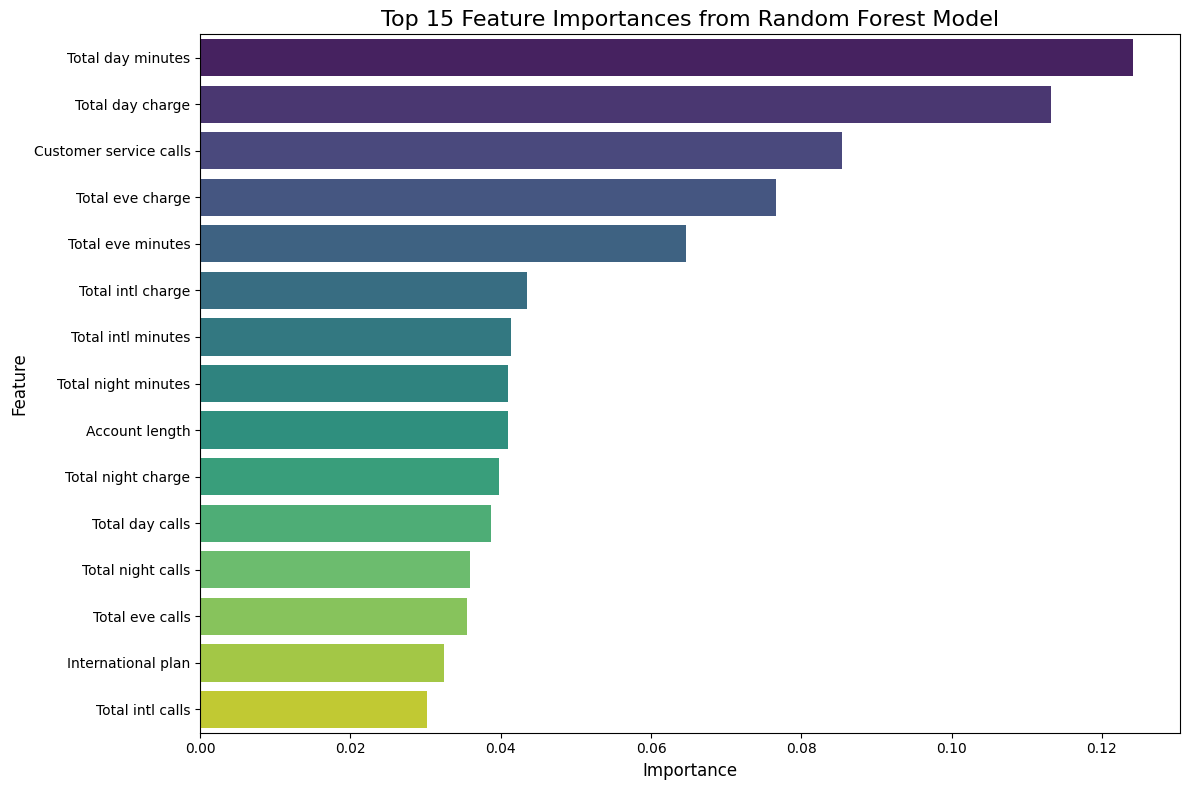

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Extract and display Logistic Regression coefficients ---
print("\n--- Logistic Regression Coefficients ---")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})
coefficients['Absolute_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Absolute_Coefficient', ascending=False)
print(coefficients.drop('Absolute_Coefficient', axis=1))

# --- 2. Extract and plot Random Forest Feature Importances ---
print("\n--- Random Forest Feature Importances ---")
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance and select top N features
top_n = 15 # Adjust as needed
feature_importances = feature_importances.sort_values(by='Importance', ascending=False).head(top_n)

print(f"Top {top_n} Random Forest Feature Importances:")
print(feature_importances)

# Create a bar plot for feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis', hue='Feature', legend=False)
plt.title(f'Top {top_n} Feature Importances from Random Forest Model', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

## Conclusion & Ethics

### Conclusion
This project successfully developed and evaluated machine learning models for customer churn prediction within the telecom industry. The **Random Forest Classifier** generally outperformed the **Logistic Regression model**, demonstrating higher ROC-AUC scores in cross-validation and on the test set (e.g., Random Forest CV ROC-AUC: 0.8810 vs. Logistic Regression CV ROC-AUC: 0.7572). This suggests that the Random Forest model is better at distinguishing between churning and non-churning customers due to its ability to capture complex non-linear relationships in the data.

Key drivers of churn identified by both models, particularly highlighted by the Random Forest's feature importance, include:
*   **Usage-related metrics**: 'Total day minutes', 'Total day charge', 'Total eve charge', and 'Total eve minutes' were consistently among the most influential features, indicating that excessive or changing usage patterns significantly impact churn likelihood.
*   **Customer service interactions**: 'Customer service calls' proved to be a strong predictor, suggesting that frequent calls for support might indicate dissatisfaction or unresolved issues leading to churn.
*   **International Plan**: Having an 'International plan' also showed a notable impact, with Logistic Regression coefficients specifically pointing to its positive correlation with churn.
*   **State-specific factors**: Some 'State' features, particularly identified by Logistic Regression, showed varying degrees of influence on churn, highlighting potential regional differences in customer behavior or service satisfaction.

Furthermore, the Exploratory Data Analysis (EDA) revealed a **significant class imbalance** in the dataset, with a much larger proportion of non-churning customers. This finding is crucial, as it necessitated the use of appropriate evaluation metrics (like ROC-AUC and Precision-Recall curves) and potentially informed model choices, as Random Forest often handles imbalanced data better than simpler models, and would require further consideration for sampling techniques if precision/recall for the minority class were paramount.

### Ethics
Deploying a churn prediction model, while offering substantial business advantages, carries significant ethical and societal implications that must be critically considered:

*   **Bias**: Churn prediction models are trained on historical data, which may contain inherent biases. For example, if past data disproportionately shows certain demographic groups (e.g., lower-income individuals, specific age groups) churning more due to service quality issues or pricing strategies, the model might learn to unfairly predict these groups as high-risk, even if current service conditions have improved. This could lead to discriminatory practices, where these groups receive fewer retention offers or poorer service, exacerbating existing inequalities.

*   **Targeting Vulnerable Customers**: Identifying customers at high risk of churning raises the ethical dilemma of how these insights are used. Aggressively targeting financially vulnerable customers with predatory retention offers (e.g., locking them into long, expensive contracts) or exploiting those struggling with service issues rather than genuinely addressing their concerns, is unethical. Such practices can harm customers and erode trust in the company.

*   **Data Privacy Concerns**: Churn prediction relies on extensive customer data, including usage patterns, billing information, and potentially sensitive demographic details. The collection, storage, and processing of this data raise significant privacy concerns. Companies must ensure robust data security measures, comply with regulations like GDPR or CCPA, and maintain transparency with customers about how their data is used. Misuse or breach of this data could have severe consequences for individuals and the company's reputation.

*   **Transparency and Fairness**: The 'black box' nature of some complex models (like Random Forests) can make it difficult to understand *why* a customer is predicted to churn. Lack of transparency can hinder fair decision-making and make it challenging to identify and mitigate biases. Ensuring fairness requires models that are not only accurate but also interpretable, allowing for audits and explanations of predictions, and ensuring that all customer segments are treated equitably.

*   **Unintended Consequences**: The deployment of these models can lead to unforeseen negative impacts. For instance, focusing solely on retaining high-value customers might inadvertently lead to neglecting lower-value customers, potentially increasing their churn rates and reducing overall market reach. It could also create a cycle where customers who *could* churn are given incentives, while loyal customers receive none, leading to dissatisfaction among the latter.

## Interpretation of Model Results

This section interprets the findings from both the Logistic Regression and Random Forest models, translating statistical insights into actionable business strategies for customer churn prediction.

### Logistic Regression Coefficients: Business Impact

In Logistic Regression, coefficients indicate the change in the log-odds of the target variable (churn) for a one-unit increase in the predictor variable, holding other variables constant. A positive coefficient suggests that an increase in the feature's value increases the likelihood of churn, while a negative coefficient indicates a decreased likelihood of churn. The magnitude of the coefficient reflects the strength of this relationship.

Based on the Logistic Regression model, some significant features influencing churn include:

*   **International Plan (Coefficient: ~1.66)**: This highly positive coefficient indicates that customers with an international plan are significantly more likely to churn. This could be due to higher costs associated with international calls, dissatisfaction with international service quality, or perhaps these customers are more exposed to competitive international offers. **Actionable Insight**: Telecom companies should re-evaluate their international plan offerings, potentially optimizing pricing, enhancing service, or providing targeted retention offers to customers subscribed to these plans.
*   **Customer Service Calls (Coefficient: ~0.79)**: A positive coefficient here suggests that customers making more customer service calls are at a higher risk of churning. This often points to unresolved issues, repeated problems, or overall dissatisfaction with support. **Actionable Insight**: Invest in improving customer service quality, aim for first-call resolution, and proactively reach out to customers who frequently contact support to address their concerns before they escalate to churn.
*   **State-Specific Impacts (e.g., State_NJ ~0.90, State_GA ~-0.82, State_MT ~0.79)**: The varying coefficients for different states (one-hot encoded features) suggest geographical differences in churn likelihood. For instance, customers in New Jersey (State_NJ) and Montana (State_MT) show a higher propensity to churn, while those in Georgia (State_GA) are less likely. **Actionable Insight**: Regional marketing and retention strategies are crucial. Companies should investigate local market conditions, competitive landscapes, or specific service issues in high-churn states, and replicate successful strategies from low-churn states like Georgia.

### Random Forest Feature Importances: Business Influence

Random Forest feature importances quantify how much each feature contributes to the model's predictive accuracy, typically measured by the reduction in impurity (like Gini impurity) across all trees. Higher importance values mean the feature is more influential in predicting customer churn.

Based on the Random Forest model, the most influential features are:

*   **Total Day Minutes / Total Day Charge (Importances: ~0.124 / ~0.113)**: These are consistently ranked as the top features. High daily usage and associated charges are strong indicators of churn. This might suggest that heavy users are more sensitive to pricing, or that they encounter service limitations more frequently. **Actionable Insight**: Monitor customers with high daily usage/charges. Implement usage-based loyalty programs, offer personalized plans to reward high-value users, or proactively check in with them to ensure satisfaction, especially if their usage patterns change.
*   **Customer Service Calls (Importance: ~0.085)**: Similar to Logistic Regression, the number of customer service calls is highly influential. This reinforces the idea that support experience is a critical churn driver. **Actionable Insight**: This finding is robust across models. Prioritize investments in customer service training, agent empowerment, and advanced analytics to identify and resolve issues more effectively for frequently calling customers.
*   **Total Eve Charge (Importance: ~0.077)**: High charges incurred during evening hours also show significant importance. This could be linked to specific calling patterns, international calls made during these times, or usage of specific evening data plans. **Actionable Insight**: Analyze evening usage patterns and associated costs. Ensure pricing for evening services is competitive and transparent. Consider offering bundled evening plans or discounts to high-charge customers to mitigate churn risk.
*   **Total International Charge / Total International Minutes (Importances: ~0.043 / ~0.041)**: These features highlight the impact of international service usage. High international charges or minutes are strong predictors of churn. **Actionable Insight**: This corroborates the Logistic Regression finding about the 'International plan'. Companies should specifically target international service users with competitive international call rates, better roaming packages, or alternative communication solutions to retain them.

### Consolidated Actionable Insights

Both models emphasize the critical role of **customer service experience** and **usage-related charges** (especially day, evening, and international) as primary drivers of churn. The geographical aspect (`State`) also plays a significant, albeit secondary, role.

To effectively reduce customer churn, telecom providers should focus on:

1.  **Proactive Customer Support**: Identify and address issues for customers making frequent service calls. Implement quality assurance and feedback loops to improve service delivery.
2.  **Value-Based Pricing and Plans**: Re-evaluate pricing structures, particularly for high-usage customers (day, evening, international), to ensure competitiveness and perceived value. Offer personalized plans or loyalty rewards.
3.  **Targeted Retention Campaigns**: Develop region-specific and usage-specific retention campaigns. For instance, customers in high-churn states with international plans and high day usage should receive highly customized offers and dedicated support.
4.  **Service Monitoring**: Continuously monitor customer usage patterns and service interactions to detect early warning signs of dissatisfaction or churn intent.

By implementing these data-driven strategies, telecom companies can proactively mitigate churn, improve customer satisfaction, and ultimately enhance customer lifetime value.